In [1]:
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
bias_strength = 0.1
data_set_name = "folktables_income"
method_name = "fw-mrs-temperature"
bias_type = "less_negative_class"
iteration = 0

In [3]:
from utils.data_loader import load_dataset
try:
    if DATA_IS_LOADED:
        pass
except:
    _, columns, _ = load_dataset(data_set_name)
    replacer = {}
    for i, feature_name in enumerate(columns):
        replacer[i] = feature_name
DATA_IS_LOADED = True

In [4]:
load_path = f"../results/test_set_classification/{data_set_name}/{bias_type}/{bias_strength}/{method_name}/classification_results/roc_curves.json"
with open(load_path) as file:
    roc_values = json.load(file)
representative_uniform_load_path = f"../results/test_set_classification/{data_set_name}/none/1.0/uniform/classification_results/roc_curves.json"
with open(representative_uniform_load_path) as file:
    representative_roc_values = json.load(file)

biased_uniform_load_path = f"../results/test_set_classification/{data_set_name}/{bias_type}/{bias_strength}/uniform/classification_results/roc_curves.json"
with open(biased_uniform_load_path) as file:
    biased_uniform_roc_values = json.load(file)

biased_mrs_load_path = f"../results/test_set_classification/{data_set_name}/{bias_type}/{bias_strength}/mrs-forest/classification_results/roc_curves.json"
with open(biased_mrs_load_path) as file:
    biased_mrs_roc_values = json.load(file)

FileNotFoundError: [Errno 2] No such file or directory: '../results/test_set_classification/folktables_income/less_negative_class/0.1/fw-mrs-temperature/classification_results/roc_curves.json'

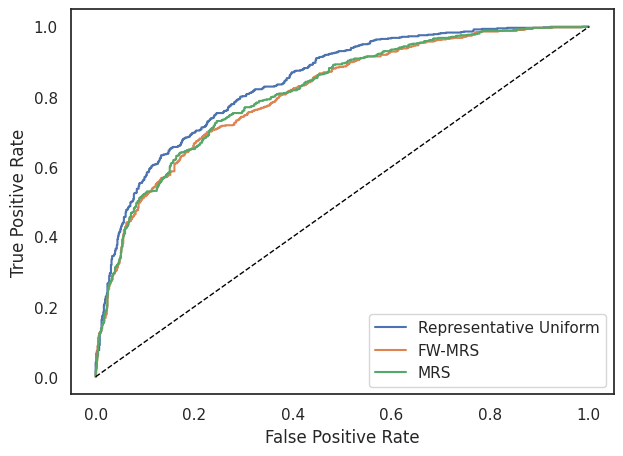

In [ ]:
sns.set_theme(rc={'figure.figsize':(7,5)})
one_iteration_roc = roc_values[iteration]
sns.set_style("white")
one_representative_roc = representative_roc_values[iteration]
one_biased_uniform_roc = biased_uniform_roc_values[iteration]
one_biased_mrs_roc = biased_mrs_roc_values[iteration]

plt.plot(one_representative_roc[0], one_representative_roc[1], label="Representative Uniform")
plt.plot(one_iteration_roc[0], one_iteration_roc[1], label="FW-MRS")
#plt.plot(one_biased_uniform_roc[0], one_biased_uniform_roc[1], label="Biased Uniform")
plt.plot(one_biased_mrs_roc[0], one_biased_mrs_roc[1], label="MRS")
plt.plot(
        [0, 1], [0, 1], color="black", linestyle="--", linewidth=1
    )

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

In [ ]:
load_path = f"../results/test_set_classification/{data_set_name}/{bias_type}/{bias_strength}/{method_name}/classification_results/feature_importance.json"
with open(load_path) as file:
    feature_importance = json.load(file)
representative_uniform_load_path = f"../results/test_set_classification/{data_set_name}/none/1.0/uniform/classification_results/feature_importance.json"
with open(representative_uniform_load_path) as file:
    representative_feature_importance = json.load(file)

biased_uniform_load_path = f"../results/test_set_classification/{data_set_name}/{bias_type}/{bias_strength}/uniform/classification_results/feature_importance.json"
with open(biased_uniform_load_path) as file:
    biased_uniform_feature_importance = json.load(file)

biased_mrs_load_path = f"../results/test_set_classification/{data_set_name}/{bias_type}/{bias_strength}/mrs-forest/classification_results/feature_importance.json"
with open(biased_uniform_load_path) as file:
    biased_mrs_feature_importance = json.load(file)

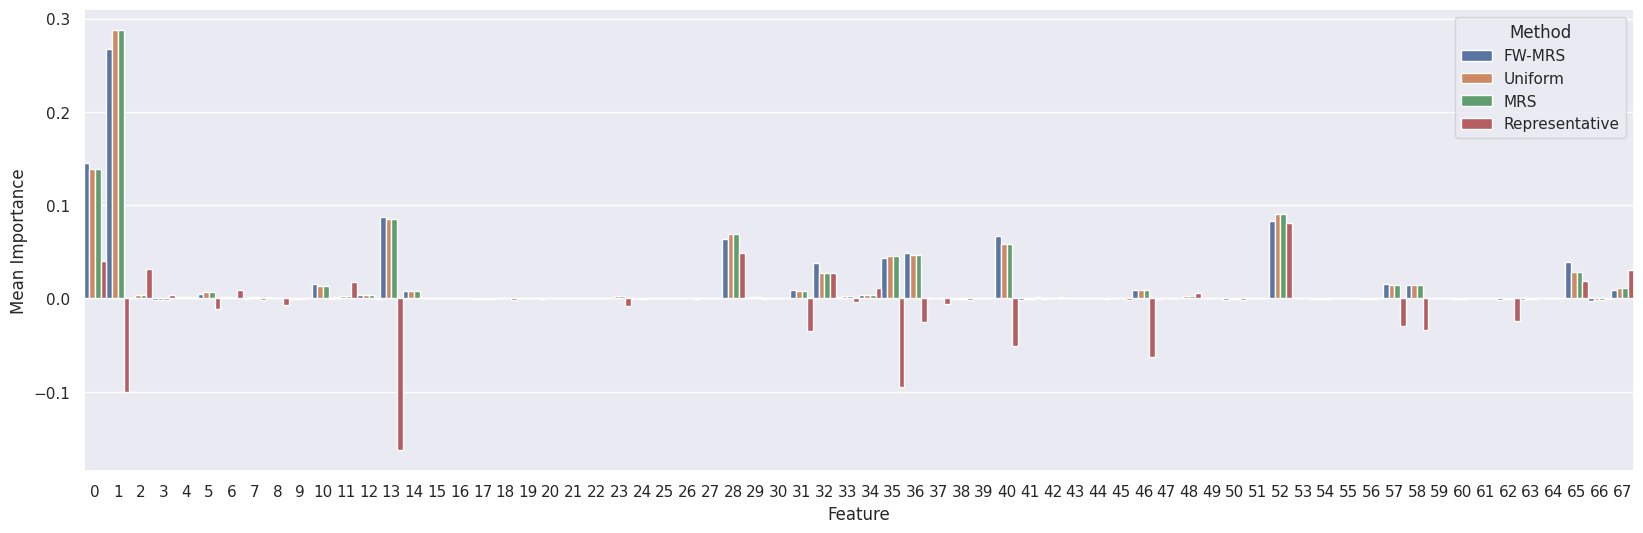

In [ ]:
sns.set_theme(rc={'figure.figsize':(20,6)})
mean_iteration_feature_importance = np.mean(feature_importance, axis=0)
mean_iteration_feature_importance /= np.sum(np.abs(mean_iteration_feature_importance))

mean_representative_feature_importance = np.mean(representative_feature_importance, axis=0)
mean_representative_feature_importance /=  np.sum(np.abs(mean_representative_feature_importance))

mean_biased_uniform_feature_importance = np.mean(biased_uniform_feature_importance, axis=0)
mean_biased_uniform_feature_importance /= np.sum(np.abs(mean_biased_uniform_feature_importance))

one_biased_mrs_feature_importance = np.mean(biased_mrs_feature_importance, axis=0)
one_biased_mrs_feature_importance /= np.sum(np.abs(one_biased_mrs_feature_importance))

feature_importances = pd.DataFrame(
    [
        {"Method": "FW-MRS", "Mean Importance": mean_iteration_feature_importance},
        {"Method": "Uniform", "Mean Importance": mean_biased_uniform_feature_importance},
        {"Method": "MRS", "Mean Importance": one_biased_mrs_feature_importance},
        {"Method": "Representative", "Mean Importance": mean_representative_feature_importance},
     ]
        )
feature_importances = feature_importances.explode(["Mean Importance"])
feature_importances['Feature'] = feature_importances.groupby('Method').cumcount()
ax = sns.barplot(feature_importances, x="Feature" , y="Mean Importance", hue="Method", width=1)

In [ ]:
load_path = f"../results/test_set_classification/{data_set_name}/{bias_type}/{bias_strength}/{method_name}/classification_results/abs_feature_importance.json"
with open(load_path) as file:
    feature_importance = json.load(file)
representative_uniform_load_path = f"../results/test_set_classification/{data_set_name}/none/1.0/uniform/classification_results/abs_feature_importance.json"
with open(representative_uniform_load_path) as file:
    representative_feature_importance = json.load(file)

biased_uniform_load_path = f"../results/test_set_classification/{data_set_name}/{bias_type}/{bias_strength}/uniform/classification_results/abs_feature_importance.json"
with open(biased_uniform_load_path) as file:
    biased_uniform_feature_importance = json.load(file)

biased_mrs_load_path = f"../results/test_set_classification/{data_set_name}/{bias_type}/{bias_strength}/mrs-forest/classification_results/abs_feature_importance.json"
with open(biased_uniform_load_path) as file:
    biased_mrs_feature_importance = json.load(file)

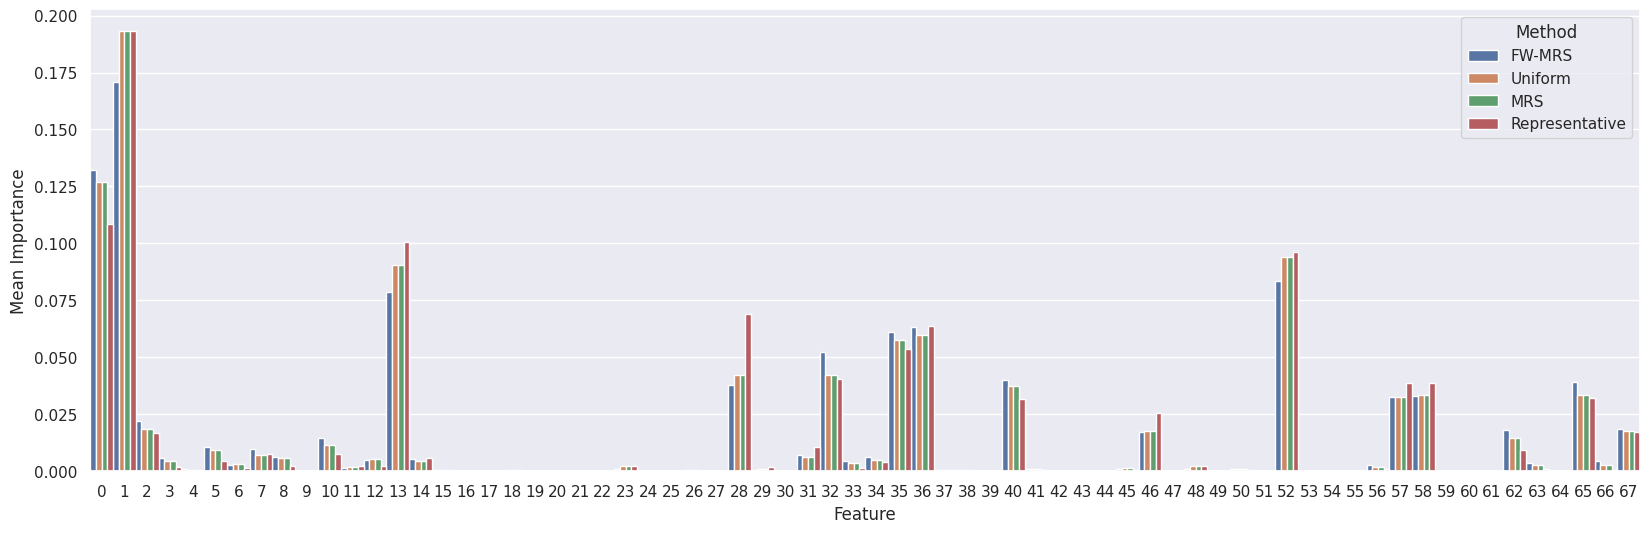

In [ ]:
sns.set_theme(rc={'figure.figsize':(20,6)})
mean_iteration_feature_importance = np.mean(feature_importance, axis=0)
mean_iteration_feature_importance /= np.sum(mean_iteration_feature_importance)

mean_representative_feature_importance = np.mean(representative_feature_importance, axis=0)
mean_representative_feature_importance /=  np.sum(mean_representative_feature_importance)

mean_biased_uniform_feature_importance = np.mean(biased_uniform_feature_importance, axis=0)
mean_biased_uniform_feature_importance /= np.sum(mean_biased_uniform_feature_importance)

one_biased_mrs_feature_importance = np.mean(biased_mrs_feature_importance, axis=0)
one_biased_mrs_feature_importance /= np.sum(one_biased_mrs_feature_importance)

feature_importances = pd.DataFrame(
    [
        {"Method": "FW-MRS", "Mean Importance": np.array(mean_iteration_feature_importance)},
        {"Method": "Uniform", "Mean Importance": np.array(mean_biased_uniform_feature_importance)},
        {"Method": "MRS", "Mean Importance": np.array(one_biased_mrs_feature_importance)},
        {"Method": "Representative", "Mean Importance": np.array(mean_representative_feature_importance)},
     ]
        )
feature_importances = feature_importances.explode(["Mean Importance"])
feature_importances['Feature'] = feature_importances.groupby('Method').cumcount()
ax = sns.barplot(feature_importances, x="Feature" , y="Mean Importance", hue="Method", width=1)

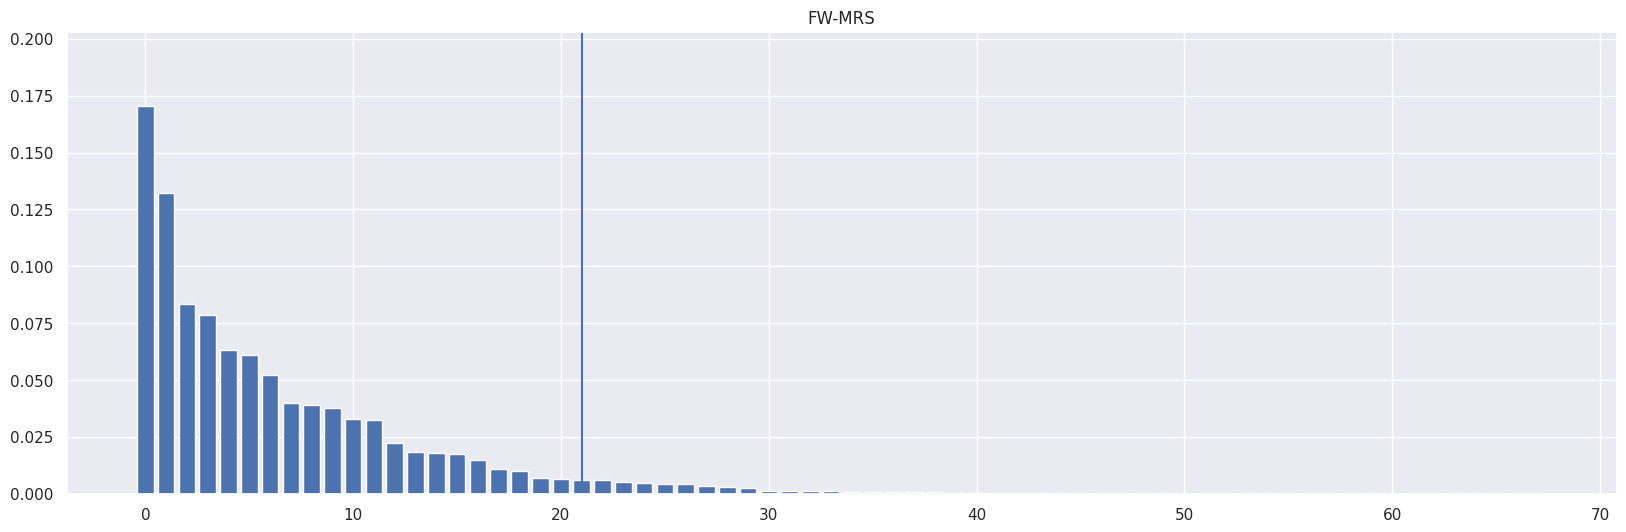

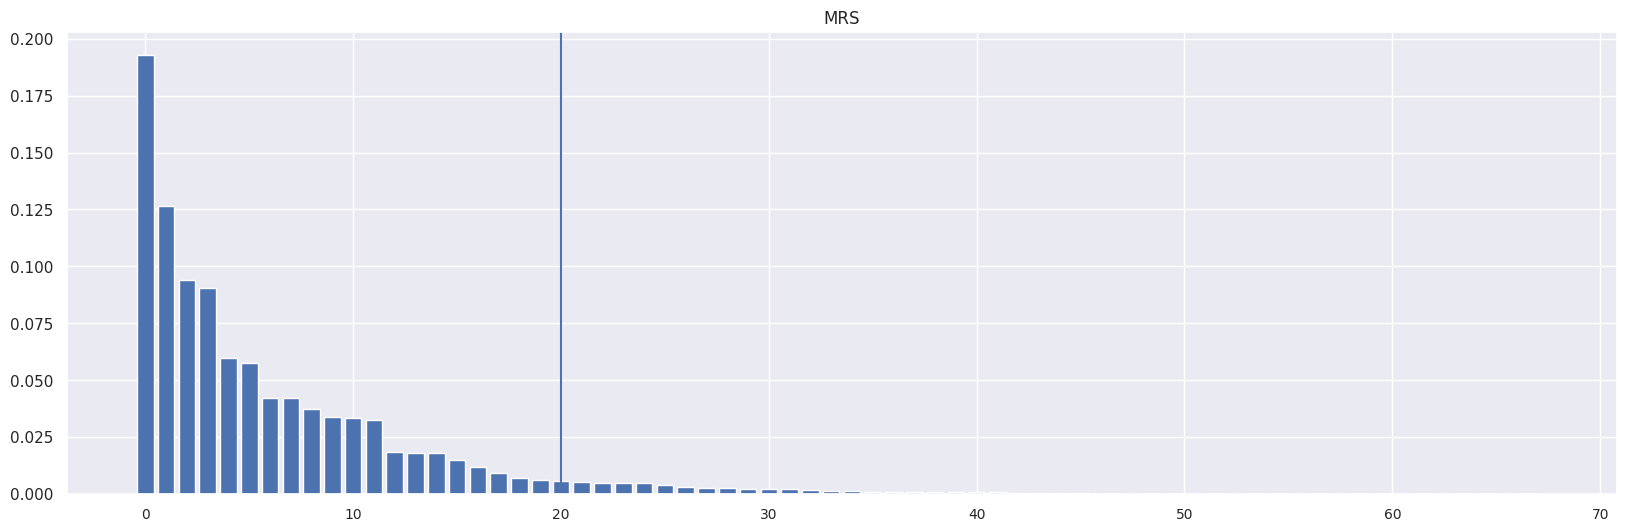

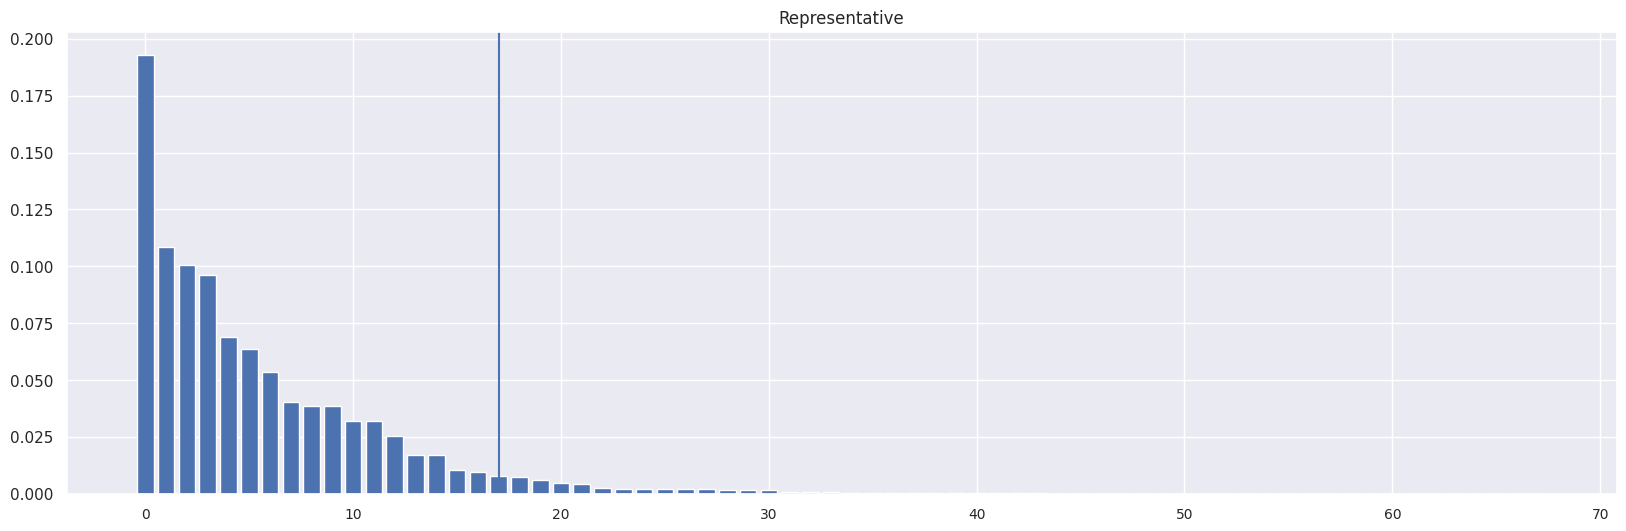

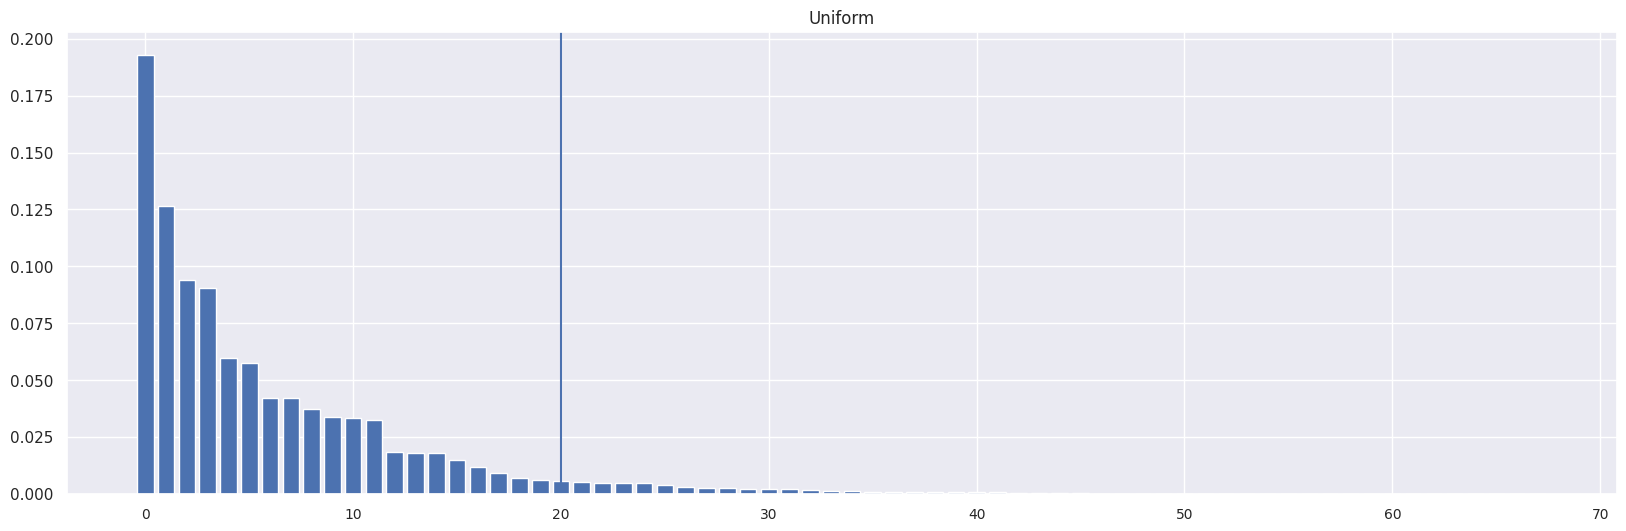

In [ ]:
xticks, xlabels = [], []
feature_importances['Mean Importance'] = feature_importances['Mean Importance'].astype("float32")
# feature_importances["Feature"] = feature_importances["Feature"].astype(str)
feature_importances["Feature"] = feature_importances["Feature"].replace(replacer)
max_importance = np.max(feature_importances['Mean Importance'])
cut = 0.95
for (idx, group) in feature_importances.groupby('Method'):
    plot_data = group.nlargest(len(columns), 'Mean Importance')
    x = [x for x in range(len(columns))]
    sum_value = 0
    for i, value in enumerate(plot_data["Mean Importance"]):
        sum_value+= value
        if sum_value >= cut:
            break
    plt.axvline(i)
    plt.bar(x=x, height=plot_data['Mean Importance'])
    plt.title(idx)
    xticks += x
    
    xlabels += plot_data['Feature'].tolist()
    plt.ylim(0, max_importance + 0.01)

    plt.rcParams['xtick.labelsize'] = 10
    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels)
    # plt.xticks(rotation = 90)
    plt.show()

In [ ]:
feature_importances["Feature"] = feature_importances["Feature"].replace(replacer)
tmp = feature_importances.sort_values(["Method", "Mean Importance"], ascending=False)
print(tmp)

     Method  Mean Importance  \
1   Uniform         0.193114   
1   Uniform         0.126734   
1   Uniform         0.094152   
1   Uniform         0.090591   
1   Uniform         0.059631   
..      ...              ...   
0    FW-MRS         0.000000   
0    FW-MRS         0.000000   
0    FW-MRS         0.000000   
0    FW-MRS         0.000000   
0    FW-MRS         0.000000   

                                              Feature  
1                                                WKHP  
1                                                AGEP  
1                               RELP_Reference person  
1                              SCHL_Bachelor's degree  
1             MAR_Never married or under 15 years old  
..                                                ...  
0                                   RELP_Foster child  
0                                     RELP_Grandchild  
0                        RELP_Stepson or stepdaughter  
0                           RAC1P_Alaska Native alone  

In [ ]:
tmp.groupby("Method").head(10)

,Method,Mean Importance,Feature
1,Uniform,0.193114,WKHP
1,Uniform,0.126734,AGEP
1,Uniform,0.094152,RELP_Reference person
1,Uniform,0.090591,SCHL_Bachelor's degree
1,Uniform,0.059631,MAR_Never married or under 15 years old
1,Uniform,0.057642,MAR_Married
1,Uniform,0.042260,SCHL_Master's degree
1,Uniform,0.042212,SCHL_Regular high school diploma
1,Uniform,0.037456,RELP_Biological son or daughter
1,Uniform,0.033625,SEX_Male
